# GAME OF LIFE

### Python modules

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, FuncFormatter
from IPython.display import HTML
import scipy as sp

### Implementing the rules

In [2]:
L = 50
frames = 500
interval = 100

def count_neighbors(world):
    return ( np.roll(world,1,0) + np.roll(world,-1,0) + np.roll(world,1,1) + np.roll(world,-1,1) +
             np.roll(np.roll(world,1,0),1,1) + np.roll(np.roll(world,1,0),-1,1) + 
             np.roll(np.roll(world,-1,0),1,1) + np.roll(np.roll(world,-1,0),-1,1) )

def evolve(world):
    neighbors = count_neighbors(world)
    new_world = np.zeros(world.shape)
    mask = ( (world==1) & ( (neighbors==2) | (neighbors==3) ) ) | ( (world==0) & (neighbors==3) )
    new_world[mask] = 1
    return new_world

# world = np.random.randint(0, 2, (L, L))
# # T = 1000 
# # for i in range(T):
# #     world = evolve(world)

# fig, ax = plt.subplots(figsize=(6,6))
# ax.axis('off')
# img = ax.imshow(np.zeros((L,L,3)), interpolation='nearest')

# def update(frame):
#     global world
#     world = evolve(world)
#     rgb = np.zeros((L,L,3))
#     rgb[world==1] = [0, 1, 1]
#     rgb[world==0] = [0, 0, 0]
#     img.set_data(rgb)
#     return [img]

# ani = FuncAnimation(fig, update, frames=frames, interval=interval, blit=True)

# HTML(ani.to_jshtml())

## Dynamic of the game 

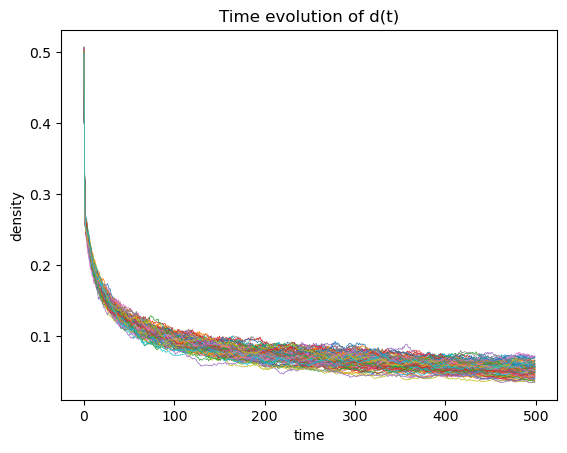

In [14]:
L = 150
T = 500
N = 100 #trajectories generated
time = np.arange(T)
initial_density = 0.5
densities = []
for i in range(N):
    aux_density = []
    world = np.random.random((L,L))
    world[world > initial_density] = 0
    world[world != 0] = 1
    for j in range(T):
        aux_density.append(np.sum(world)/L**2)
        world = evolve(world)
    plt.plot(time,aux_density, lw = 0.5)
    densities.append(aux_density)
plt.xlabel("time")
plt.ylabel("density")
plt.title("Time evolution of d(t)")
plt.show()

The various generated worlds exhibit a similar d(t) function.

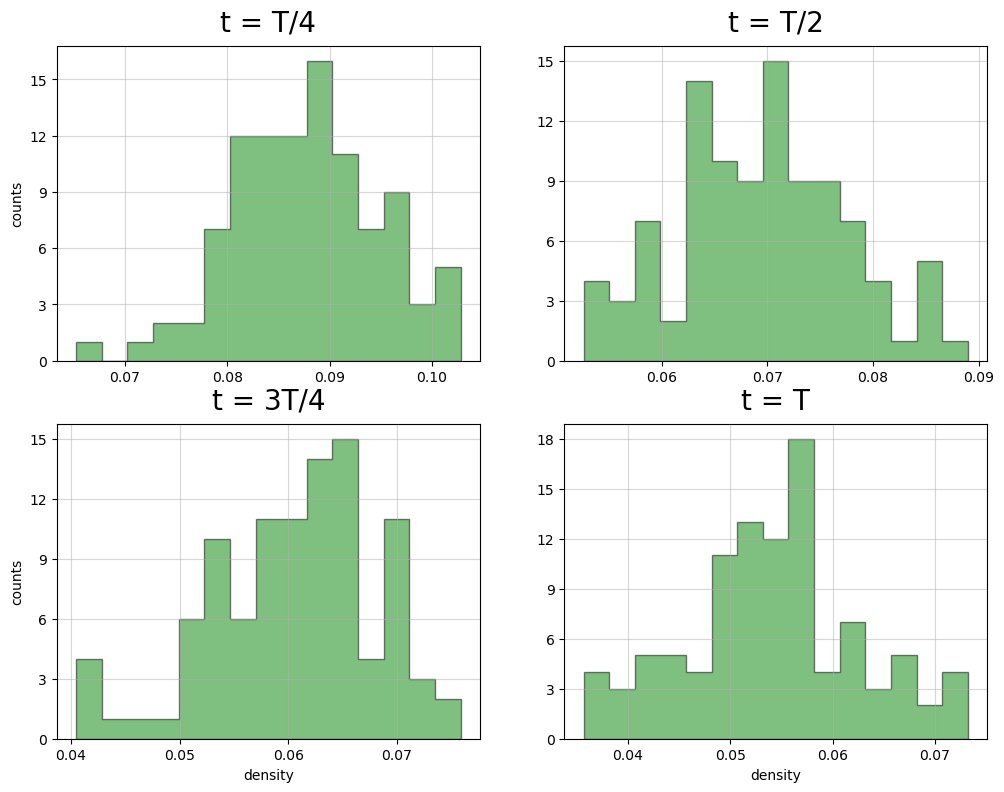

In [28]:
densities = np.array(densities)

fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize=(12, 9))

ax[0][0].hist(densities[:,int(T/4)],15, histtype = 'stepfilled', alpha = 0.5, color = 'green', edgecolor = "black")
ax[0][0].yaxis.set_major_locator(MultipleLocator(3))
ax[0][0].xaxis.set_major_locator(MultipleLocator(0.01))
ax[0][0].set_title("t = T/4", fontsize=20, verticalalignment='bottom')
ax[0][0].grid(alpha=0.5)

ax[0][1].hist(densities[:,int(T/2)],15, histtype = 'stepfilled', alpha = 0.5, color = 'green', edgecolor = "black")
ax[0][1].yaxis.set_major_locator(MultipleLocator(3))
ax[0][1].xaxis.set_major_locator(MultipleLocator(0.01))
ax[0][1].set_title("t = T/2", fontsize=20, verticalalignment='bottom')
ax[0][1].grid(alpha=0.5)

ax[1][0].hist(densities[:,int(3*T/4)],15, histtype = 'stepfilled', alpha = 0.5, color = 'green', edgecolor = "black")
ax[1][0].yaxis.set_major_locator(MultipleLocator(3))
ax[1][0].xaxis.set_major_locator(MultipleLocator(0.01))
ax[1][0].set_title("t = 3T/4", fontsize=20, verticalalignment='bottom')
ax[1][0].grid(alpha=0.5)

ax[1][1].hist(densities[:,T-1],15, histtype = 'stepfilled', alpha = 0.5, color = 'green', edgecolor = "black")
ax[1][1].yaxis.set_major_locator(MultipleLocator(3))
ax[1][1].xaxis.set_major_locator(MultipleLocator(0.01))
ax[1][1].set_title("t = T", fontsize=20, verticalalignment='bottom')
ax[1][1].grid(alpha=0.5)

ax[1][0].set_xlabel("density")
ax[1][1].set_xlabel("density")
ax[0][0].set_ylabel("counts")
ax[1][0].set_ylabel("counts")

plt.show()

These seems to be well behaved distributions. We proceed by calculating mean trajectories and errors.

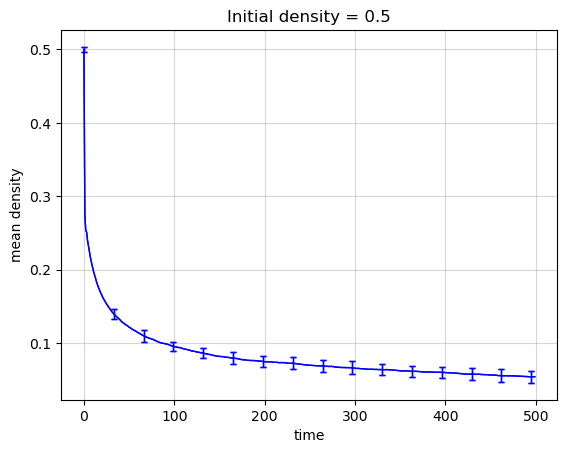

In [32]:
mean_density = densities.mean(axis = 0)
std_density = densities.std(axis = 0)
idx = list(range(0,T,int(T/15)))
plt.errorbar(time[idx],mean_density[idx],std_density[idx], ls = '', lw = 1, capsize = 2, color = 'blue')
plt.plot(time,mean_density, ls = '-', lw = 1, color = 'blue')
plt.xlabel("time")
plt.ylabel("mean density")
plt.title("Initial density = 0.5")
plt.grid(alpha = 0.5)
plt.show()

Now let's see how different initial densities influence the time evolution.

In [35]:
T = 1000
N = 50
initial_densities = [0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 0.6, 0.65, 0.7, 0.75, 0.8]

mean_densities = []
mean_std = []
for d in initial_densities:
    densities = []
    for i in range(N):
        aux_density = []
        world = np.random.random((L,L))
        world[world > d] = 0
        world[world != 0] = 1
        for t in range(T):
            aux_density.append(np.sum(world)/L**2)
            world = evolve(world)
        densities.append(aux_density)
    mean_std.append(np.array(densities).std(axis=0))
    mean_densities.append(np.array(densities).mean(axis=0))

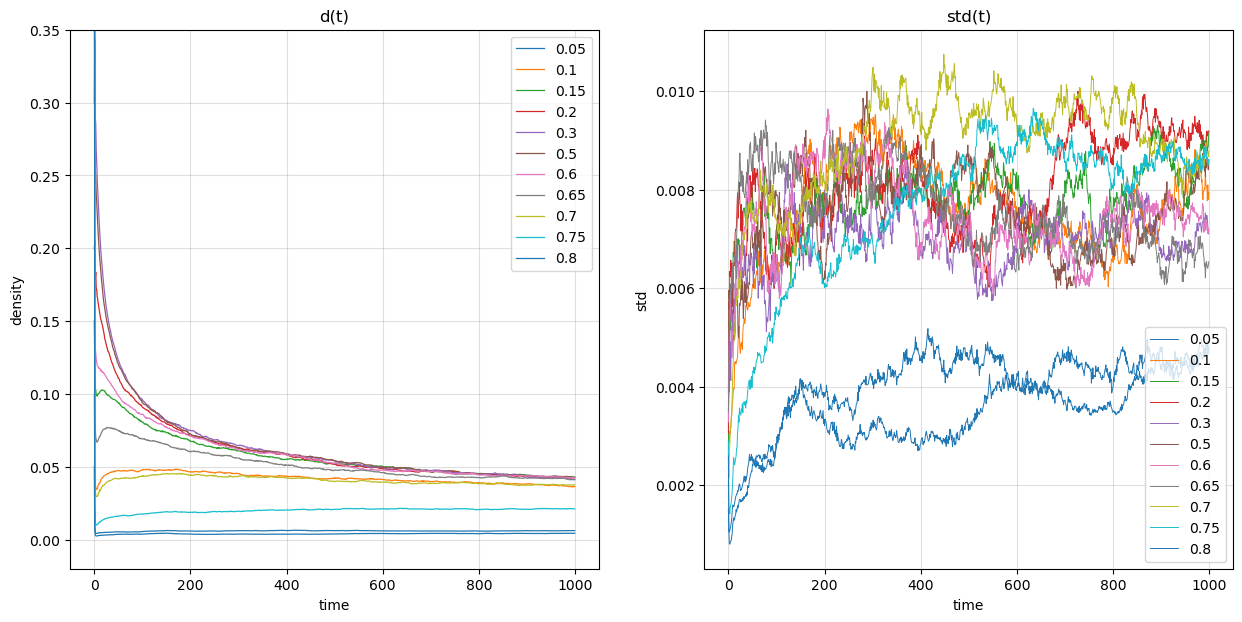

In [43]:
fig, (ax1,ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (15,7))

for i in range(len(mean_densities)):
    ax1.plot(range(T), mean_densities[i], lw = 0.9, label = f"{initial_densities[i]}")
    ax2.plot(range(T), mean_std[i], lw = 0.7, label = f"{initial_densities[i]}")

ax1.set_xlabel("time")
ax1.set_ylabel("density")
ax1.set_title("d(t)")
ax1.set_ylim(-0.02,0.35)
ax2.set_xlabel("time")
ax2.set_ylabel("std")
ax2.set_title("std(t)")
ax1.legend()
ax2.legend()
ax1.grid(alpha = 0.4)
ax2.grid(alpha = 0.4)
plt.show()

No matter of the initial density, many trajectories seem to converge to an asymptotic value. Let's have a closer look.

In [4]:
L = 80
T = 7000
DT = 500
N = 10
initial_densities = np.concatenate([np.arange(0,0.1,0.01), np.arange(0.1,0.7,0.1), np.arange(0.7, 0.9, 0.01)])
asymptotic_densities = []
std_densities = []
for d in initial_densities:
    aux_density = []
    for i in range(N):
        world = np.random.random((L,L))
        world[world > d] = 0
        world[world != 0] = 1
        for t in range(T):
            world = evolve(world)
        for t in range(T+DT):
            aux_density.append(np.sum(world)/L**2)
            world = evolve(world)
    asymptotic_densities.append(np.array(aux_density).mean())
    std_densities.append(np.array(aux_density).std())
print("Completed")

Completed


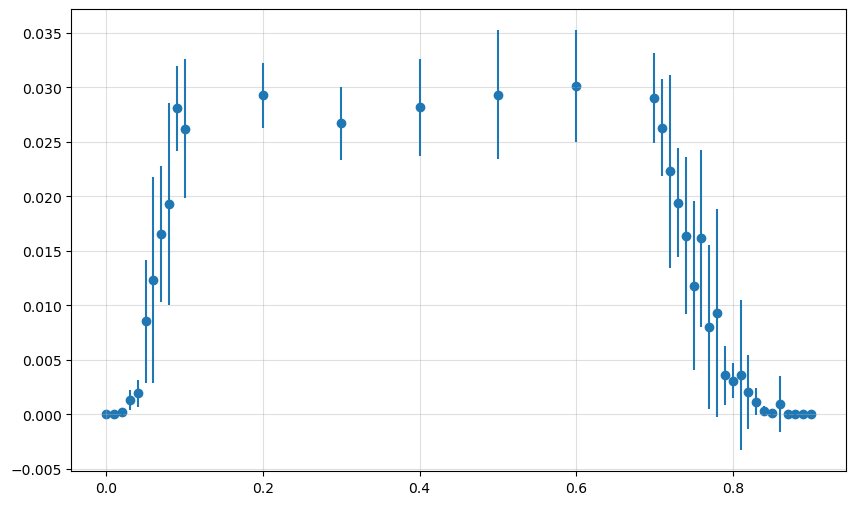

In [6]:
fig, ax = plt.subplots(figsize = (10,6))
ax.errorbar(initial_densities, asymptotic_densities, std_densities, ls = "")
ax.scatter(initial_densities, asymptotic_densities)
plt.grid(alpha = 0.4)
plt.show()